In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/nikitajoshidata8/superstore-dataset/superstore.csv
/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv',encoding='latin-1'

print("Shape:",df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


SyntaxError: '(' was never closed (1770740736.py, line 5)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin-1')

# Basic inspection
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
df.describe()

In [ ]:
# Convert date columns from text to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful columns from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')

# Calculate shipping days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Confirm changes
print("Updated Data Types:")
print(df[['Order Date', 'Ship Date']].dtypes)
print("\nNew Columns Added:")
print(df[['Order Year', 'Order Month', 'Order Month Name', 'Shipping Days']].head())

In [ ]:
# Total Sales, Profit and Quantity
print("Total Sales: $", round(df['Sales'].sum(), 2))
print("Total Profit: $", round(df['Profit'].sum(), 2))
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())
print("Average Shipping Days:", round(df['Shipping Days'].mean(), 1))

# Sales and Profit by Region
print("\nSales and Profit by Region:")
region_summary = df.groupby('Region')[['Sales','Profit']].sum().round(2)
print(region_summary)

# Sales and Profit by Category
print("\nSales and Profit by Category:")
category_summary = df.groupby('Category')[['Sales','Profit']].sum().round(2)
print(category_summary)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Analysis', fontsize=16)

# Chart 1: Sales by Region
region_summary['Sales'].plot(kind='bar', ax=axes[0,0], 
color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
axes[0,0].set_title('Total Sales by Region')
axes[0,0].set_xlabel('Region')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2: Profit by Region
region_summary['Profit'].plot(kind='bar', ax=axes[0,1],
color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
axes[0,1].set_title('Total Profit by Region')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Profit ($)')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3: Sales by Category
category_summary['Sales'].plot(kind='bar', ax=axes[1,0],
color=['#F44336','#2196F3','#4CAF50'])
axes[1,0].set_title('Total Sales by Category')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].tick_params(axis='x', rotation=0)

# Chart 4: Profit by Category
category_summary['Profit'].plot(kind='bar', ax=axes[1,1],
color=['#F44336','#2196F3','#4CAF50'])
axes[1,1].set_title('Total Profit by Category')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Profit ($)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

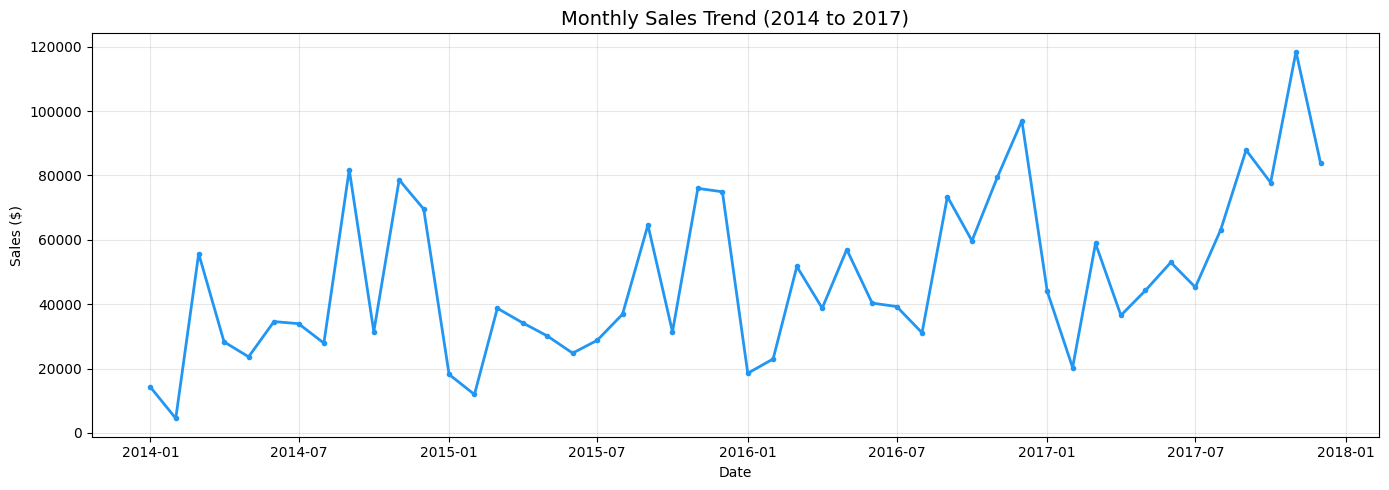

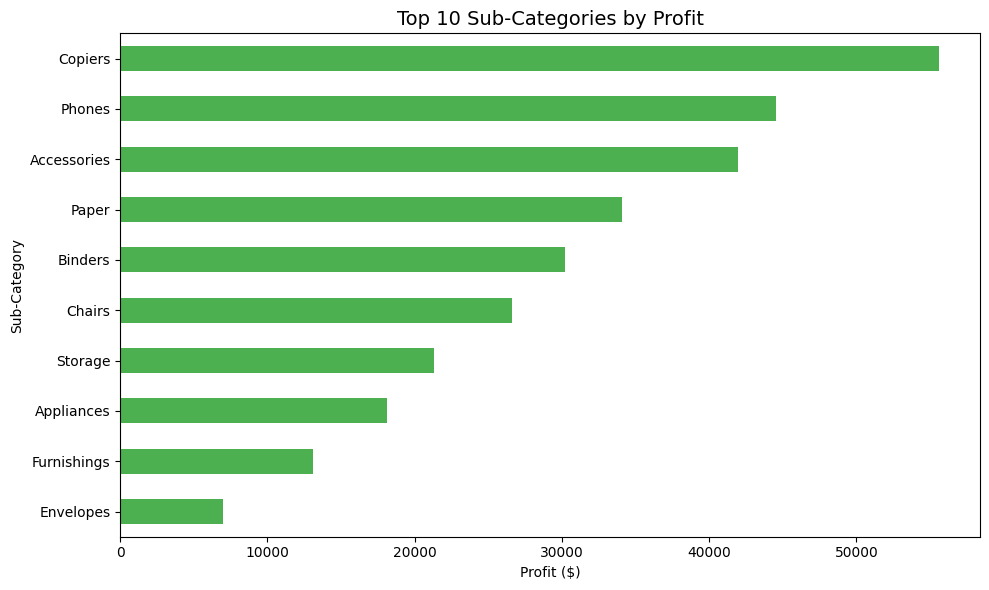

Charts saved.


In [12]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Order Year', 'Order Month']].assign(day=1).rename(columns={'Order Year':'year','Order Month':'month'}))

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         color='#2196F3', linewidth=2, marker='o', markersize=3)
plt.title('Monthly Sales Trend (2014 to 2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 Sub-Categories by Profit
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
subcategory_profit.plot(kind='barh', color='#4CAF50')
plt.title('Top 10 Sub-Categories by Profit', fontsize=14)
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")

# Superstore Sales Analysis: Business Insights

## Project Summary
Analyzed 9,994 transactions across 4 regions and 3 product categories 
from 2014 to 2017. Total revenue of $2.29M with a profit of $286K 
representing a 12.5% overall profit margin.

## Key Findings

### 1. West Region Leads Performance
West generates the highest sales ($725K) and profit ($108K). 
Central region shows a margin problem: $501K in sales but only 
$39K profit, the lowest margin of all regions.

### 2. Furniture Is a Loss Risk
Furniture generates $742K in sales but only $18K in profit. 
This is a 2.5% margin compared to Technology's 17.4% margin. 
High discounting in Furniture is likely eroding profits.

### 3. Technology Drives Profitability
Copiers, Phones, and Accessories are the top 3 most profitable 
sub-categories. Technology should be the focus of sales growth strategy.

### 4. Seasonal Sales Pattern
Sales peak every November and December across all years. 
The business should increase inventory and marketing spend 
in Q4 to capture maximum demand.

### 5. Average Shipping Time is 4 Days
Consistent across all regions. No major logistics issues detected.

## Business Recommendations

1. Reduce discounts on Furniture products, especially in Central region.
2. Increase Technology product promotions in South region which 
   has the lowest overall sales.
3. Plan Q4 inventory and campaigns in advance to capture 
   seasonal demand peaks.
4. Investigate Central region operations to identify 
   why margins are 3x lower than West region.

In [13]:
print("Analysis Complete")
print("Total Charts Created: 6")
print("Key Insights: 5")
print("Business Recommendations: 4")
print("\nNext Step: Save Version and publish notebook")

Analysis Complete
Total Charts Created: 6
Key Insights: 5
Business Recommendations: 4

Next Step: Save Version and publish notebook


In [14]:
print("Analysis Complete")
print("Total Charts Created: 6")
print("Key Insights: 5")
print("Business Recommendations: 4")

Analysis Complete
Total Charts Created: 6
Key Insights: 5
Business Recommendations: 4
